## step 1 :Import Libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OrdinalEncoder, OneHotEncoder, RobustScaler

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import VotingRegressor, StackingRegressor,RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet

from sklearn.pipeline import make_pipeline, Pipeline

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

import pickle

import warnings
warnings.filterwarnings("ignore")


## step 2 :Load the dataset

In [2]:
car_df = pd.read_csv("car_price_prediction.csv")
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

## step 3 :data Preprocessing

In [3]:
# Head

car_df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


## Car Price Prediction Dataset – Columns
- **ID – Unique number for each car record (not useful for prediction).**

- **Levy – Additional tax/fee applied to the car price.**

- **Manufacturer – Brand/company of the car (Toyota, BMW, etc.).**

- **Model – Specific car model name.**

- **Prod. year – Year the car was manufactured.**

- **Category – Type/body style of the car (Sedan, SUV, Hatchback, etc.).**

- **Leather interior – Indicates whether the car has leather seats (Yes/No).**

- **Fuel type – Type of fuel used (Petrol, Diesel, Hybrid, Electric, etc.).**

- **Engine volume – Engine size or capacity of the car.**

- **Mileage – Total distance the car has been driven.**

- **Cylinders – Number of engine cylinders.**

- **Gear box type – Transmission type (Manual, Automatic, etc.).**

- **Drive wheels – Wheel drive system (FWD, RWD, AWD/4x4).**

- **Doors – Number of doors in the car.**

- **Wheel – Steering wheel side (Left or Right).**

- **Color – Exterior color of the car.**

- **Airbags – Number of airbags installed for safety.**

- **Price – Selling price of the car (target variable).**

### Replace "-" into "NAN"

In [4]:
car_df["Levy"] = car_df["Levy"].replace("-", np.nan)
car_df["Levy"] = car_df["Levy"].astype(float)

- **Levy column cleaned – Replaced “-” with NaN and converted to float so it becomes a proper numeric feature.**

In [5]:
car_df["Engine volume"].value_counts().tail(10)

Engine volume
0.3 Turbo    1
5.4 Turbo    1
0.4 Turbo    1
0.2 Turbo    1
5.7 Turbo    1
6.8          1
6.7          1
3.1          1
0.8 Turbo    1
1.1 Turbo    1
Name: count, dtype: int64

### Create Turbo Features and Extract numeric part

In [6]:
car_df["Turbo"] = car_df["Engine volume"].str.contains("Turbo", na=False).astype("int64")
car_df["Engine volume"] = car_df["Engine volume"].str.extract(r"([\d\.]+)")
car_df["Engine volume"] = car_df["Engine volume"].astype(float)

- **Turbo feature created – New binary column (1 = Turbo, 0 = Non-Turbo) extracted from engine text.**

- **Engine volume numeric extracted – Removed the word “Turbo” and kept only the numeric engine size.**

- **Engine volume converted to float – Now usable for regression models and scaling.**

In [9]:
car_df["Mileage"].unique()

array(['186005 km', '192000 km', '200000 km', ..., '140607 km',
       '307325 km', '186923 km'], dtype=object)

### Remove Km from "Mileage" column and change the datatype 

In [10]:
car_df["Mileage"] = car_df["Mileage"].str.replace(" km", "", regex=False)
car_df["Mileage"] = car_df["Mileage"].astype(float)


- **Removed text units and converted to float so the ML model can interpret mileage numerically.**

In [11]:
car_df["Leather interior"].value_counts()

Leather interior
Yes    13954
No      5283
Name: count, dtype: int64

In [13]:
car_df["Leather interior"] = car_df["Leather interior"].map({"Yes":1, "No":0})


In [14]:
car_df["Leather interior"].value_counts()

Leather interior
1    13954
0     5283
Name: count, dtype: int64

- **We convert Yes/No to 0/1 because ML models require numeric input, and binary encoding preserves information while reducing dimensionality and improving computational efficiency.**

### Percentage of Null Values

In [15]:
car_df.isnull().sum()/len(car_df) * 100

ID                   0.000000
Price                0.000000
Levy                30.248999
Manufacturer         0.000000
Model                0.000000
Prod. year           0.000000
Category             0.000000
Leather interior     0.000000
Fuel type            0.000000
Engine volume        0.000000
Mileage              0.000000
Cylinders            0.000000
Gear box type        0.000000
Drive wheels         0.000000
Doors                0.000000
Wheel                0.000000
Color                0.000000
Airbags              0.000000
Turbo                0.000000
dtype: float64

<Axes: >

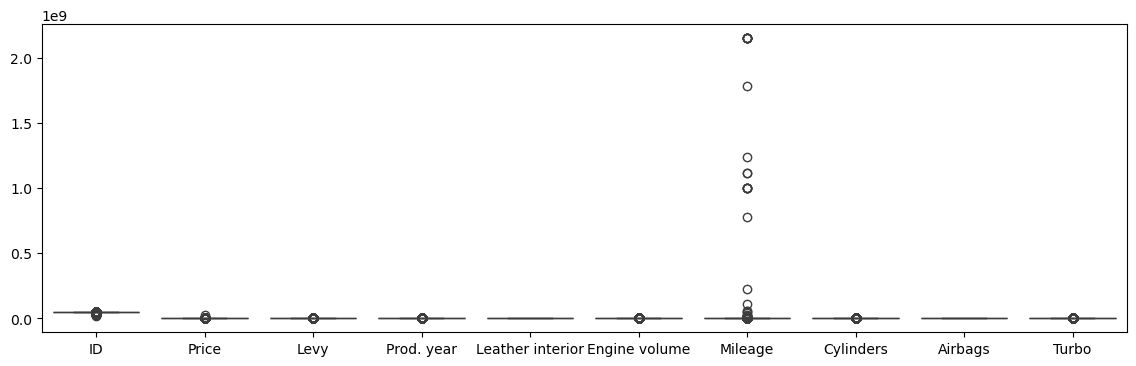

In [16]:
plt.figure(figsize=(14, 4))
sns.boxplot(car_df)

- **Levy had ~30% missing values and they were not missing at random.**
- **Median imputation reduced variance and weakened its correlation with price.**
- **Dropping those rows improved R² because it removed noisy records and preserved true predictive patterns.**

In [17]:
car_df = car_df.dropna(subset=["Levy"])
car_df.reset_index(drop=True, inplace=True)

In [18]:
# car_df["Levy"].fillna(car_df["Levy"].median(), inplace=True)

In [19]:
car_df.isnull().sum()/len(car_df) * 100

ID                  0.0
Price               0.0
Levy                0.0
Manufacturer        0.0
Model               0.0
Prod. year          0.0
Category            0.0
Leather interior    0.0
Fuel type           0.0
Engine volume       0.0
Mileage             0.0
Cylinders           0.0
Gear box type       0.0
Drive wheels        0.0
Doors               0.0
Wheel               0.0
Color               0.0
Airbags             0.0
Turbo               0.0
dtype: float64

In [20]:
car_df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Turbo
0,45654403,13328,1399.0,LEXUS,RX 450,2010,Jeep,1,Hybrid,3.5,186005.0,6.0,Automatic,4x4,04-May,Left wheel,Silver,12,0
1,44731507,16621,1018.0,CHEVROLET,Equinox,2011,Jeep,0,Petrol,3.0,192000.0,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8,0
2,45769185,3607,862.0,FORD,Escape,2011,Jeep,1,Hybrid,2.5,168966.0,4.0,Automatic,4x4,04-May,Left wheel,White,0,0
3,45809263,11726,446.0,HONDA,FIT,2014,Hatchback,1,Petrol,1.3,91901.0,4.0,Automatic,Front,04-May,Left wheel,Silver,4,0
4,45802912,39493,891.0,HYUNDAI,Santa FE,2016,Jeep,1,Diesel,2.0,160931.0,4.0,Automatic,Front,04-May,Left wheel,White,4,0


### Adding New Car_Age Column [present_year - Prod. Year] And Drop the "Prod. year" column

In [21]:

current_year = datetime.now().year

car_df["Car_Age"] = current_year - car_df["Prod. year"]

car_df.drop(columns="Prod. year", inplace= True)
car_df.head(3)

,ID,Price,Levy,Manufacturer,Model,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Turbo,Car_Age
0,45654403,13328,1399.0,LEXUS,RX 450,Jeep,1,Hybrid,3.5,186005.0,6.0,Automatic,4x4,04-May,Left wheel,Silver,12,0,16
1,44731507,16621,1018.0,CHEVROLET,Equinox,Jeep,0,Petrol,3.0,192000.0,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8,0,15
2,45769185,3607,862.0,FORD,Escape,Jeep,1,Hybrid,2.5,168966.0,4.0,Automatic,4x4,04-May,Left wheel,White,0,0,15


**--> ID:** It is a unique identifier with no predictive information and can introduce spurious patterns. <br>

**--> Doors:** It is largely redundant as the same information is captured by category or body type.<br>

**--> Wheel:** It has low variance and minimal influence on price, making it a weak predictor.<br>

**--> Model:** It is a high-cardinality categorical feature that increases model complexity and overfitting risk.<br>

**-->Color:** It has low correlation with price and mainly adds noise rather than useful signal.

In [22]:
car_df.drop(columns=["ID", "Doors", "Wheel", "Model", "Color"], inplace=True)

In [23]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13418 entries, 0 to 13417
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             13418 non-null  int64  
 1   Levy              13418 non-null  float64
 2   Manufacturer      13418 non-null  object 
 3   Category          13418 non-null  object 
 4   Leather interior  13418 non-null  int64  
 5   Fuel type         13418 non-null  object 
 6   Engine volume     13418 non-null  float64
 7   Mileage           13418 non-null  float64
 8   Cylinders         13418 non-null  float64
 9   Gear box type     13418 non-null  object 
 10  Drive wheels      13418 non-null  object 
 11  Airbags           13418 non-null  int64  
 12  Turbo             13418 non-null  int64  
 13  Car_Age           13418 non-null  int64  
dtypes: float64(4), int64(5), object(5)
memory usage: 1.4+ MB


In [24]:
car_df["Price"] = car_df["Price"].astype("float")

- **I converted the target variable to float to maintain datatype consistency and ensure compatibility with scaling and mathematical transformations.**

In [25]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13418 entries, 0 to 13417
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             13418 non-null  float64
 1   Levy              13418 non-null  float64
 2   Manufacturer      13418 non-null  object 
 3   Category          13418 non-null  object 
 4   Leather interior  13418 non-null  int64  
 5   Fuel type         13418 non-null  object 
 6   Engine volume     13418 non-null  float64
 7   Mileage           13418 non-null  float64
 8   Cylinders         13418 non-null  float64
 9   Gear box type     13418 non-null  object 
 10  Drive wheels      13418 non-null  object 
 11  Airbags           13418 non-null  int64  
 12  Turbo             13418 non-null  int64  
 13  Car_Age           13418 non-null  int64  
dtypes: float64(5), int64(4), object(5)
memory usage: 1.4+ MB


<Axes: >

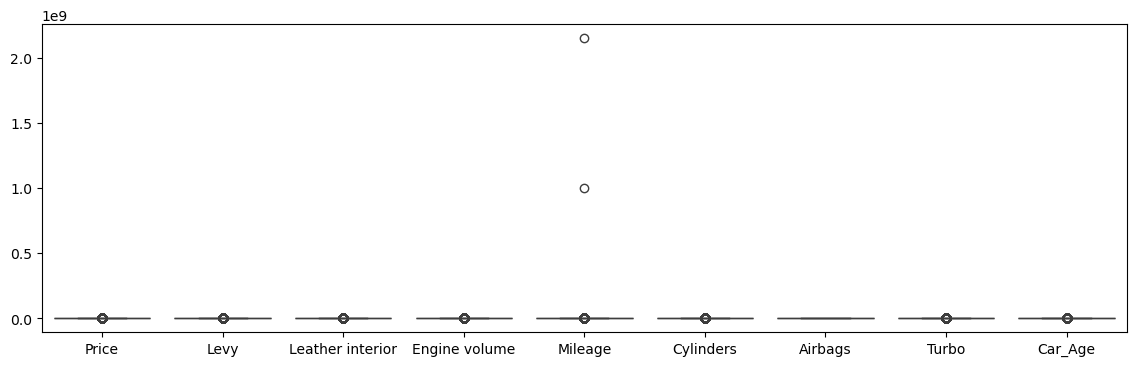

In [26]:
plt.figure(figsize=(14, 4))
sns.boxplot(car_df)

In [27]:
num_cols = ['Price','Levy','Engine volume','Mileage']

for col in num_cols:
    Q1 = car_df[col].quantile(0.25)
    Q3 = car_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    car_df[col] = car_df[col].clip(lower, upper)


- **I handled outliers using IQR-based capping on continuous numerical features like Price, Levy, Engine Volume, and Mileage. This reduced extreme skewness without removing data points.**

<Axes: >

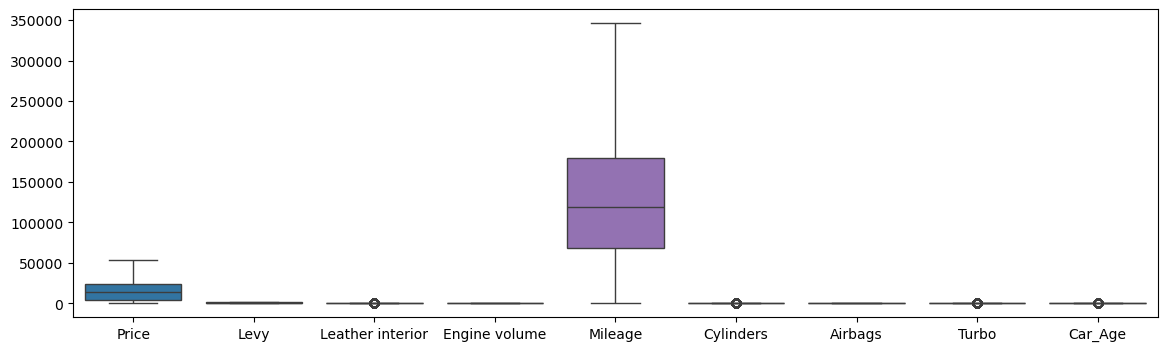

In [28]:
plt.figure(figsize=(14, 4))
sns.boxplot(car_df)

## step 4 :selecting Target variable and Predictors

In [29]:
y = car_df["Price"]
X = car_df.drop(columns="Price")

X.shape, y.shape

((13418, 13), (13418,))

## step 5 :Splitting the data

In [30]:

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((9392, 13), (4026, 13), (9392,), (4026,))

- **I used a 70:30 train–test split because the dataset size is moderate (~13–14k rows). 70% data is sufficient for the model to learn meaningful patterns, while 30% provides enough unseen data for reliable evaluation. This balance helps measure generalization performance and detect overfitting effectively.**

## Step 6:Preprocessing

- **I used One-Hot Encoding because the categorical features were nominal with no inherent order.**
- **One-Hot preserves category independence and avoids artificial relationships.**
- **I used RobustScaler because the dataset contained significant outliers in features like mileage and levy.**

In [31]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9392 entries, 3821 to 6365
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Levy              9392 non-null   float64
 1   Manufacturer      9392 non-null   object 
 2   Category          9392 non-null   object 
 3   Leather interior  9392 non-null   int64  
 4   Fuel type         9392 non-null   object 
 5   Engine volume     9392 non-null   float64
 6   Mileage           9392 non-null   float64
 7   Cylinders         9392 non-null   float64
 8   Gear box type     9392 non-null   object 
 9   Drive wheels      9392 non-null   object 
 10  Airbags           9392 non-null   int64  
 11  Turbo             9392 non-null   int64  
 12  Car_Age           9392 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 1.0+ MB


In [32]:

trans = ColumnTransformer(transformers=[("t1", RobustScaler(), [0,5,6,7,12]),
                                       ("t2", OneHotEncoder(handle_unknown='ignore', sparse_output=False), [1,2,4,8,9])],
                          remainder="passthrough")
X_train_trans = trans.fit_transform(X_train)
X_test_trans = trans.transform(X_test)

type(X_train_trans), type(X_test_trans)

(numpy.ndarray, numpy.ndarray)

- **`handle_unknown='ignore'` → avoids crash if new brand appears in test.**

- **`sparse_output=False` → returns normal array instead of sparse matrix.**

- **Since I already applied IQR-based capping, StandardScaler would also work. However, I preferred RobustScaler because the features still showed mild skewness, and RobustScaler is more stable to residual extremes.**

In [33]:
feature_names = trans.get_feature_names_out()
#feature_names

In [34]:
# Converting Numpy Array into DataFrame
#X_train_trans = pd.DataFrame(X_train_trans, columns=X_train.columns)
#X_test_trans = pd.DataFrame(X_test_trans, columns=X_train.columns)

#type(X_train_trans),X_train_trans.shape, type(X_test_trans), X_test_trans.shape


feature_names = trans.get_feature_names_out()

X_train_trans = pd.DataFrame(X_train_trans, columns=feature_names)
X_test_trans  = pd.DataFrame(X_test_trans,  columns=feature_names)
type(X_train_trans),X_train_trans.shape, type(X_test_trans), X_test_trans.shape

(pandas.core.frame.DataFrame,
 (9392, 80),
 pandas.core.frame.DataFrame,
 (4026, 80))

## Step 7:Model Building
## Decision Tree

In [35]:
dt_model = DecisionTreeRegressor()

dt_model.fit(X_train_trans, y_train)

DecisionTreeRegressor()

In [36]:
# Prediction 
DT_y_pred = dt_model.predict(X_test_trans)
DT_X_pred = dt_model.predict(X_train_trans)

In [37]:
# Score
print("Decision Tree Test Data R2 Score : ", r2_score(y_test, DT_y_pred))
print("Decision Tree Train Data R2 Score : ",r2_score(y_train, DT_X_pred))

Decision Tree Test Data R2 Score :  0.6905680960513731
Decision Tree Train Data R2 Score :  0.9827617734545121


In [40]:
dt = DecisionTreeRegressor(random_state=42)

param_grid = {
    "max_depth": [4, 6, 8, 10, 14, None],
    "min_samples_leaf": [5, 10, 20, 30],
    "min_samples_split": [20, 50, 100],
    "max_features": ["sqrt", None]
}
grid = GridSearchCV(
    dt,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train_trans, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV R2 Score:", grid.best_score_)


Best Parameters: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best CV R2 Score: 0.7249219849257422


In [42]:
dt_model = DecisionTreeRegressor(max_depth=None,
                                 min_samples_leaf=5,
                                 min_samples_split=20,
                                 max_features=None,
                                 random_state=42
                               )

dt_model.fit(X_train_trans, y_train)

DecisionTreeRegressor(min_samples_leaf=5, min_samples_split=20, random_state=42)

In [43]:
# Prediction 
DT_y_pred = dt_model.predict(X_test_trans)
DT_X_pred = dt_model.predict(X_train_trans)

In [44]:
# Score

print("Decision Tree Test Data R2 Score : ", r2_score(y_test, DT_y_pred))
print("Decision Tree Train Data R2 Score : ",r2_score(y_train, DT_X_pred))
print()
print("Decision Tree Test Data MAE : ", mean_absolute_error(y_test, DT_y_pred))
print("Decision Tree Test Data MSE : ", mean_squared_error(y_test, DT_y_pred))
print("Decision Tree Test Data RMSE : ", root_mean_squared_error(y_test, DT_y_pred))

Decision Tree Test Data R2 Score :  0.7211960360956473
Decision Tree Train Data R2 Score :  0.843041478643839

Decision Tree Test Data MAE :  4724.852217541652
Decision Tree Test Data MSE :  58665570.90015067
Decision Tree Test Data RMSE :  7659.345331041725


In [45]:

dt_model.feature_importances_

array([5.13129528e-02, 7.21784925e-02, 1.07596587e-01, 1.22912976e-02,
       2.49828532e-01, 0.00000000e+00, 1.61032915e-03, 0.00000000e+00,
       3.39003791e-04, 0.00000000e+00, 0.00000000e+00, 4.14051378e-03,
       0.00000000e+00, 0.00000000e+00, 5.24380319e-04, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 8.53593369e-04,
       0.00000000e+00, 0.00000000e+00, 2.34818106e-03, 0.00000000e+00,
       3.82860998e-03, 0.00000000e+00, 7.38164634e-04, 0.00000000e+00,
       7.21175034e-04, 0.00000000e+00, 0.00000000e+00, 2.06218658e-03,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.19505461e-03,
       0.00000000e+00, 0.00000000e+00, 1.28533434e-04, 4.00522715e-06,
       1.77937116e-05, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 4.23129670e-04, 6.18695274e-04,
       0.00000000e+00, 0.00000000e+00, 3.88577343e-03, 0.00000000e+00,
       3.32999510e-04, 0.00000000e+00, 0.00000000e+00, 9.65949528e-04,
      

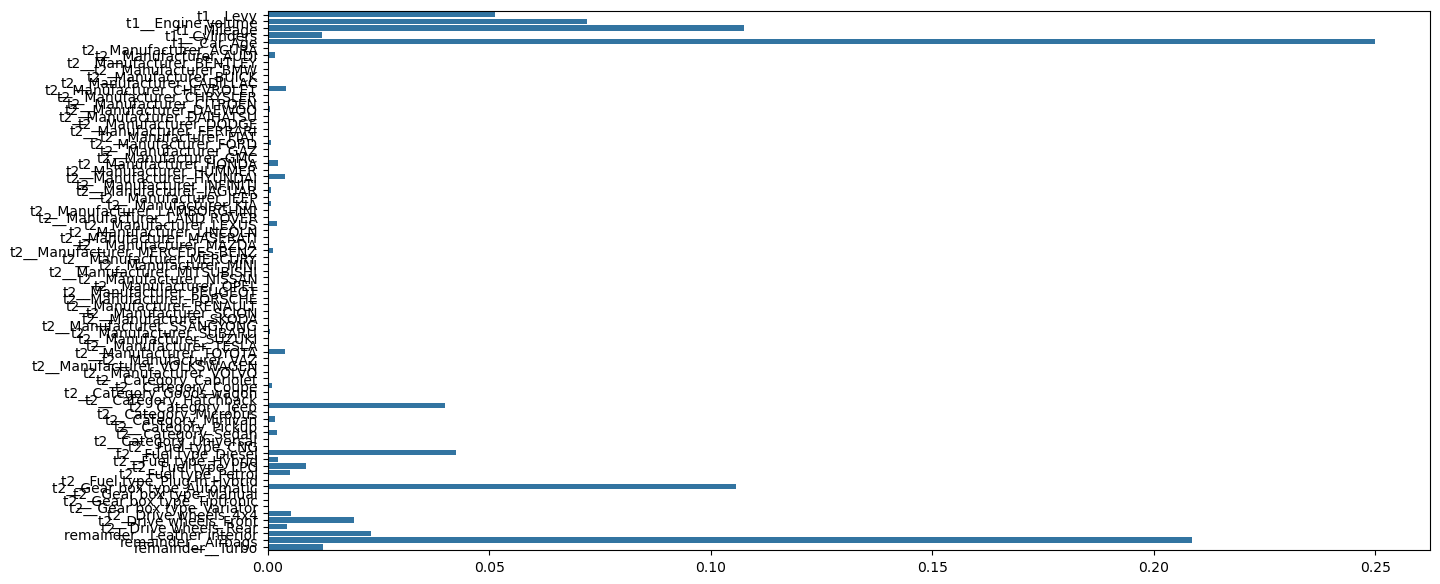

In [46]:
plt.figure(figsize=(15, 7))
sns.barplot(x = dt_model.feature_importances_, y = feature_names)

plt.show()

# KNN Algoritham

In [47]:
# Random Forest

knn_model = KNeighborsRegressor()
knn_model.fit(X_train_trans, y_train)

KNeighborsRegressor()

In [48]:
knn_y_pred = knn_model.predict(X_test_trans)
knn_X_pred = knn_model.predict(X_train_trans)

In [49]:
print("KNN Test Data R2 Score : ", r2_score(y_test, knn_y_pred))
print("KNN Train Data R2 Score : ", r2_score(y_train, knn_X_pred))

KNN Test Data R2 Score :  0.7457438889831096
KNN Train Data R2 Score :  0.8431284733847515


In [50]:

knn_pipe = make_pipeline(trans, KNeighborsRegressor())

tuned_parameters = [{
    "kneighborsregressor__n_neighbors": list(range(1, 51)),
    "kneighborsregressor__p": [1, 2, 3]
}]

search = RandomizedSearchCV(knn_pipe,
                      param_distributions=tuned_parameters,
                      cv = 5,
                      scoring="r2",
                      return_train_score= True
                     )

search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('t1',
                                                                               RobustScaler(),
                                                                               [0,
                                                                                5,
                                                                                6,
                                                                                7,
                                                                                12]),
                                                                              ('t2',
                                                                               OneHotEncoder(handle_unknown='ignore',
                                                                                             sparse_output=False),
                                                                               [1,
                                                                                2,
                                                                                4,
                                                                                8,
                                                                                9])])),
                                             ('kneighborsregressor',
                                              KNeighborsRegressor())]),
                   param_distributions=[{'kneighborsregressor__n_neighbors': [1,
                                                                              2,
                                                                              3,
                                                                              4,
                                                                              5,
                                                                              6,
                                                                              7,
                                                                              8,
                                                                              9,
                                                                              10,
                                                                              11,
                                                                              12,
                                                                              13,
                                                                              14,
                                                                              15,
                                                                              16,
                                                                              17,
                                                                              18,
                                                                              19,
                                                                              20,
                                                                              21,
                                                                              22,
                                                                              23,
                                                                              24,
                                                                              25,
                                                                              26,
                                                                              27,
                                                                              28,
                                                       

In [51]:
print(search.best_params_)
print(search.best_estimator_)

print("Score: ", search.score(X_test, y_test))

{'kneighborsregressor__p': 2, 'kneighborsregressor__n_neighbors': 3}
Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [0, 5, 6, 7, 12]),
                                                 ('t2',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 2, 4, 8, 9])])),
                ('kneighborsregressor', KNeighborsRegressor(n_neighbors=3))])
Score:  0.7453983166321271


In [52]:

knn_model = KNeighborsRegressor(n_neighbors=3)
knn_model.fit(X_train_trans, y_train)

KNeighborsRegressor(n_neighbors=3)

In [53]:
knn_y_pred = knn_model.predict(X_test_trans)
knn_X_pred = knn_model.predict(X_train_trans)

In [54]:
print("KNN Test Data R2 Score : ", r2_score(y_test, knn_y_pred))
print("KNN Train Data R2 Score : ", r2_score(y_train, knn_X_pred))

KNN Test Data R2 Score :  0.7453983166321271
KNN Train Data R2 Score :  0.8806443039710052


# Random Forest

In [55]:
# Model
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Hyperparameter Grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [6, 10, 14, 18, 22, None],
    "min_samples_split": [10, 20, 50],
    "min_samples_leaf": [5, 10, 15],
    "max_features": ["sqrt", "log2", None]
}

# Grid Search
grid_rf = RandomizedSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Fit
grid_rf.fit(X_train_trans, y_train)

# Results
print("Best Parameters:", grid_rf.best_params_)
print("Best CV R2 Score:", grid_rf.best_score_)


Best Parameters: {'n_estimators': 100, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': None, 'max_depth': 14}
Best CV R2 Score: 0.7648590339175702


In [57]:
# Random Forest
RFR_model =make_pipeline(trans, RandomForestRegressor(max_depth=14,
                                  n_estimators=100,
                                  min_samples_leaf=5,
                                  min_samples_split=20,
                                  max_features=None))


RFR_model.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [0, 5, 6, 7, 12]),
                                                 ('t2',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 2, 4, 8, 9])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=14, max_features=None,
                                       min_samples_leaf=5,
                                       min_samples_split=20))])

In [58]:
RF_y_pred = RFR_model.predict(X_test)
RF_X_pred = RFR_model.predict(X_train)

In [59]:
print("Random Forest Test Data R2 Score : ", r2_score(y_test, RF_y_pred))
print("Random Forest Train Data R2 Score : ", r2_score(y_train, RF_X_pred))

Random Forest Test Data R2 Score :  0.7572973564712204
Random Forest Train Data R2 Score :  0.8410878380680737


### Create Pipe line 

In [60]:
# Pipeline (preprocessing + model)
pipe = Pipeline([("preprocess", trans),("model", RandomForestRegressor(random_state=42,n_jobs=-1))])

# Hyperparameter space (prefix with model__)
param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [6, 10, 14, None],
    "model__min_samples_split": [10, 20, 50],
    "model__min_samples_leaf": [5, 10, 20],
    "model__max_features": ["sqrt", None]
}

# Randomized Search
search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=29
)

search.fit(X_train, y_train)

print("Best Parameters:", search.best_params_)
print("Best CV R2:", search.best_score_)


Best Parameters: {'model__n_estimators': 300, 'model__min_samples_split': 20, 'model__min_samples_leaf': 5, 'model__max_features': None, 'model__max_depth': None}
Best CV R2: 0.7671921953289037


In [61]:
best_model = search.best_estimator_

# Train & test performance
print("Train R2:", best_model.score(X_train, y_train))
print("Test R2 :", best_model.score(X_test, y_test))


Train R2: 0.8479634292457754
Test R2 : 0.7627855473591937


# Linear Regression

In [62]:
from sklearn.linear_model import SGDRegressor
LR_model = make_pipeline(trans, SGDRegressor(
    max_iter=5000,
    learning_rate='adaptive',
    eta0=0.001,
    penalty='l2'
)
)
LR_model.fit(X_train, y_train)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [0, 5, 6, 7, 12]),
                                                 ('t2',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 2, 4, 8, 9])])),
                ('sgdregressor',
                 SGDRegressor(eta0=0.001, learning_rate='adaptive',
                              max_iter=5000))])

In [63]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor

sgd = SGDRegressor(
    max_iter=10000,
    eta0=0.00001,
    learning_rate='adaptive',
    penalty='l2',
    alpha=0.0001
)

LR_model = make_pipeline(trans, TransformedTargetRegressor(
    regressor=sgd,
    transformer=StandardScaler()))

LR_model.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [0, 5, 6, 7, 12]),
                                                 ('t2',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 2, 4, 8, 9])])),
                ('transformedtargetregressor',
                 TransformedTargetRegressor(regressor=SGDRegressor(eta0=1e-05,
                                                                   learning_rate='adaptive',
                                                                   max_iter=10000),
                                            transformer=StandardScaler()))])

In [64]:
#LR_y_pred = LR_model.predict(X_test)
LR_y_pred = LR_model.predict(X_test)
print(y_test.shape, LR_y_pred.shape)

LR_X_pred = LR_model.predict(X_train)
print(y_train.shape, LR_X_pred.shape)

(4026,) (4026,)
(9392,) (9392,)


In [65]:
print("Gradient Decent Regression Test Data R2 Score : ", r2_score(y_test, LR_y_pred))
print("Gradient Decent Train Data R2 Score : ", r2_score(y_train, LR_X_pred))
print()
print("Gradient Decent Test Data MAE : ", mean_absolute_error(y_test, LR_y_pred))
print("Gradient Decent Test Data MSE : ", mean_squared_error(y_test, LR_y_pred))
print("Gradient Decent Test Data RMSE : ", root_mean_squared_error(y_test, LR_y_pred))

Gradient Decent Regression Test Data R2 Score :  0.3396378776686245
Gradient Decent Train Data R2 Score :  0.35465781568538357

Gradient Decent Test Data MAE :  8964.397262462768
Gradient Decent Test Data MSE :  138952547.03299597
Gradient Decent Test Data RMSE :  11787.813496700564


In [66]:
LR_pipe = make_pipeline(trans, LinearRegression())
LR_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [0, 5, 6, 7, 12]),
                                                 ('t2',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 2, 4, 8, 9])])),
                ('linearregression', LinearRegression())])

In [67]:
LR_y_pred = LR_pipe.predict(X_test)
print(y_test.shape, LR_y_pred.shape)

LR_X_pred = LR_pipe.predict(X_train)
print(y_train.shape, LR_X_pred.shape)

(4026,) (4026,)
(9392,) (9392,)


In [68]:
print("Linear Regression Test Data R2 Score : ", r2_score(y_test, LR_y_pred))
print("Linear Regression Train Data R2 Score : ", r2_score(y_train, LR_X_pred))
print()
print("Linear Regression Test Data MAE : ", mean_absolute_error(y_test, LR_y_pred))
print("Linear Regression Test Data MSE : ", mean_squared_error(y_test, LR_y_pred))
print("Linear Regression Test Data RMSE : ", root_mean_squared_error(y_test, LR_y_pred))

Linear Regression Test Data R2 Score :  0.4087308317202213
Linear Regression Train Data R2 Score :  0.4380252606733269

Linear Regression Test Data MAE :  8397.059289973102
Linear Regression Test Data MSE :  124414096.65427265
Linear Regression Test Data RMSE :  11154.106717002158


## Lasso

In [69]:
Lasso_pipe = make_pipeline(trans, Lasso())
Lasso_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [0, 5, 6, 7, 12]),
                                                 ('t2',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 2, 4, 8, 9])])),
                ('lasso', Lasso())])

In [70]:
lasso_y_pred = Lasso_pipe.predict(X_test)
print(y_test.shape, lasso_y_pred.shape)

lasso_X_pred = Lasso_pipe.predict(X_train)
print(y_train.shape, lasso_X_pred.shape)

(4026,) (4026,)
(9392,) (9392,)


In [71]:
print("Lasso Test Data R2 Score : ", r2_score(y_test, lasso_y_pred))
print("Lasso Train Data R2 Score : ", r2_score(y_train, lasso_X_pred))
print()
print("Lasso Test Data MAE : ", mean_absolute_error(y_test, lasso_y_pred))
print("Lasso Test Data MSE : ", mean_squared_error(y_test, lasso_y_pred))
print("Lasso Test Data RMSE : ", root_mean_squared_error(y_test, lasso_y_pred))

Lasso Test Data R2 Score :  0.4089632790906623
Lasso Train Data R2 Score :  0.437578527279336

Lasso Test Data MAE :  8393.806899156043
Lasso Test Data MSE :  124365185.3780476
Lasso Test Data RMSE :  11151.913978239234


## RIDGE

In [72]:
Ridge_pipe = make_pipeline(trans, Ridge())
Ridge_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [0, 5, 6, 7, 12]),
                                                 ('t2',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 2, 4, 8, 9])])),
                ('ridge', Ridge())])

In [73]:
ridge_y_pred = Ridge_pipe.predict(X_test)
print(y_test.shape, ridge_y_pred.shape)

ridge_X_pred = Ridge_pipe.predict(X_train)
print(y_train.shape, ridge_X_pred.shape)

(4026,) (4026,)
(9392,) (9392,)


In [74]:
print("Ridge Test Data R2 Score : ", r2_score(y_test, ridge_y_pred))
print("Ridge Train Data R2 Score : ", r2_score(y_train, ridge_X_pred))
print()
print("Ridge Test Data MAE : ", mean_absolute_error(y_test, ridge_y_pred))
print("Ridge Test Data MSE : ", mean_squared_error(y_test, ridge_y_pred))
print("Ridge Test Data RMSE : ", root_mean_squared_error(y_test, ridge_y_pred))

Ridge Test Data R2 Score :  0.40926454917751376
Ridge Train Data R2 Score :  0.4373747932018138

Ridge Test Data MAE :  8392.211531809726
Ridge Test Data MSE :  124301792.51450016
Ridge Test Data RMSE :  11149.071374536094


## Elastic Net

In [75]:
EN_pipe = make_pipeline(trans, ElasticNet())
EN_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [0, 5, 6, 7, 12]),
                                                 ('t2',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 2, 4, 8, 9])])),
                ('elasticnet', ElasticNet())])

In [76]:
en_y_pred = EN_pipe.predict(X_test)
print(y_test.shape, en_y_pred.shape)

en_X_pred = EN_pipe.predict(X_train)
print(y_train.shape, en_X_pred.shape)

(4026,) (4026,)
(9392,) (9392,)


In [77]:
print("Elastic Net Test Data R2 Score : ", r2_score(y_test, en_y_pred))
print("Elastic Net Train Data R2 Score : ", r2_score(y_train, en_X_pred))
print()
print("Elastic Net Test Data MAE : ", mean_absolute_error(y_test, en_y_pred))
print("Elastic Net Test Data MSE : ", mean_squared_error(y_test, en_y_pred))
print("Elastic Net Test Data RMSE : ", root_mean_squared_error(y_test, en_y_pred))

Elastic Net Test Data R2 Score :  0.27230722102441574
Elastic Net Train Data R2 Score :  0.2804928714025373

Elastic Net Test Data MAE :  9572.599871246615
Elastic Net Test Data MSE :  153120177.06163368
Elastic Net Test Data RMSE :  12374.173793091548


# Ensembles
## Voting Ensemble

In [78]:
Voting_pipe = make_pipeline(trans, VotingRegressor(estimators=[("KNN",KNeighborsRegressor()),("DT",DecisionTreeRegressor()),
                                                         ("LR",LinearRegression()),("RF",RandomForestRegressor())]))
Voting_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [0, 5, 6, 7, 12]),
                                                 ('t2',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 2, 4, 8, 9])])),
                ('votingregressor',
                 VotingRegressor(estimators=[('KNN', KNeighborsRegressor()),
                                             ('DT', DecisionTreeRegressor()),
                                             ('LR', LinearRegression()),
                                             ('RF',
                                              RandomForestRegressor())]))])

In [79]:
vote_y_pred = Voting_pipe.predict(X_test)
print(y_test.shape, vote_y_pred.shape)

vote_X_pred = Voting_pipe.predict(X_train)
print(y_train.shape, vote_X_pred.shape)

(4026,) (4026,)
(9392,) (9392,)


In [80]:
print("Voting Ensemble Test Data R2 Score : ", r2_score(y_test, vote_y_pred))
print("Voting Ensemble Train Data R2 Score : ", r2_score(y_train, vote_X_pred))
print()
print("Voting Ensemble Data MAE : ", mean_absolute_error(y_test, vote_y_pred))
print("Voting Ensemble Test Data MSE : ", mean_squared_error(y_test, vote_y_pred))
print("Voting Ensemble Test Data RMSE : ", root_mean_squared_error(y_test, vote_y_pred))

Voting Ensemble Test Data R2 Score :  0.778955512945402
Voting Ensemble Train Data R2 Score :  0.9114230128891128

Voting Ensemble Data MAE :  4478.086760700568
Voting Ensemble Test Data MSE :  46511896.19326107
Voting Ensemble Test Data RMSE :  6819.963063922052


## Stacking Ensemble

In [81]:
Stack_pipe = make_pipeline(trans, StackingRegressor(estimators=[("KNN",KNeighborsRegressor()),("DT",DecisionTreeRegressor()),
                                                         ("LR",LinearRegression())],
                                                    final_estimator=RandomForestRegressor()))
Stack_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [0, 5, 6, 7, 12]),
                                                 ('t2',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 2, 4, 8, 9])])),
                ('stackingregressor',
                 StackingRegressor(estimators=[('KNN', KNeighborsRegressor()),
                                               ('DT', DecisionTreeRegressor()),
                                               ('LR', LinearRegression())],
                                   final_estimator=RandomForestRegressor()))])

In [82]:
stack_y_pred = Stack_pipe.predict(X_test)
print(y_test.shape, stack_y_pred.shape)

stack_X_pred = Stack_pipe.predict(X_train)
print(y_train.shape, stack_X_pred.shape)

(4026,) (4026,)
(9392,) (9392,)


In [83]:
print("Stacking Ensemble Test Data R2 Score : ", r2_score(y_test, stack_y_pred))
print("Stacking Ensemble Train Data R2 Score : ", r2_score(y_train, stack_X_pred))
print()
print("Stacking Ensemble Test Data MAE : ", mean_absolute_error(y_test, stack_y_pred))
print("Stacking Ensemble Test Data MSE : ", mean_squared_error(y_test, stack_y_pred))
print("Stacking Ensemble Test Data RMSE : ", root_mean_squared_error(y_test, stack_y_pred))

Stacking Ensemble Test Data R2 Score :  0.7571532341570872
Stacking Ensemble Train Data R2 Score :  0.8931360997715626

Stacking Ensemble Test Data MAE :  4306.630169963276
Stacking Ensemble Test Data MSE :  51099503.6079086
Stacking Ensemble Test Data RMSE :  7148.391679805227


# Boosting Ensembles
## Adaptive Boosting

In [84]:
base_estimator= DecisionTreeRegressor(random_state=23)
ADA_pipe=make_pipeline(trans,AdaBoostRegressor(estimator=base_estimator, random_state=23))

In [85]:
param_dist = {
    'adaboostregressor__n_estimators': [50, 100, 150, 200, 300],
    'adaboostregressor__learning_rate': [0.001, 0.01, 0.1],
    'adaboostregressor__estimator__max_depth': [2, 3, 4, 5, 7]
}

ADA_random_search = RandomizedSearchCV(
    ADA_pipe,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

ADA_random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('t1',
                                                                               RobustScaler(),
                                                                               [0,
                                                                                5,
                                                                                6,
                                                                                7,
                                                                                12]),
                                                                              ('t2',
                                                                               OneHotEncoder(handle_unknown='ignore',
                                                                                             sparse_output=False),
                                                                               [1,
                                                                                2,
                                                                                4,
                                                                                8,
                                                                                9])])),
                                             ('adaboostregressor',
                                              AdaBoostRegressor(estimator=DecisionTreeRegressor(random_state=23),
                                                                random_state=23))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'adaboostregressor__estimator__max_depth': [2,
                                                                                    3,
                                                                                    4,
                                                                                    5,
                                                                                    7],
                                        'adaboostregressor__learning_rate': [0.001,
                                                                             0.01,
                                                                             0.1],
                                        'adaboostregressor__n_estimators': [50,
                                                                            100,
                                                                            150,
                                                                            200,
                                                                            300]},
                   random_state=42, scoring='r2')

In [86]:
print("Best Parameters:", ADA_random_search.best_params_)

Best Parameters: {'adaboostregressor__n_estimators': 300, 'adaboostregressor__learning_rate': 0.01, 'adaboostregressor__estimator__max_depth': 7}


In [87]:
base_estimator= DecisionTreeRegressor(max_depth=7)
ADA_pipe=make_pipeline(trans,AdaBoostRegressor(estimator=base_estimator, n_estimators=300, learning_rate=0.01))
ADA_pipe.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [0, 5, 6, 7, 12]),
                                                 ('t2',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 2, 4, 8, 9])])),
                ('adaboostregressor',
                 AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=7),
                                   learning_rate=0.01, n_estimators=300))])

In [88]:
adap_y_pred = ADA_pipe.predict(X_test)
print(y_test.shape, adap_y_pred.shape)

adap_X_pred = ADA_pipe.predict(X_train)
print(y_train.shape, adap_X_pred.shape)

(4026,) (4026,)
(9392,) (9392,)


In [89]:
print("Adaptive Boosting Test Data R2 Score : ", r2_score(y_test, adap_y_pred))
print("Adaptive Boosting Train Data R2 Score : ", r2_score(y_train, adap_X_pred))
print()
print("Adaptive Boosting Test Data MAE : ", mean_absolute_error(y_test, adap_y_pred))
print("Adaptive Boosting Test Data MSE : ", mean_squared_error(y_test, adap_y_pred))
print("Adaptive Boosting Test Data RMSE : ", root_mean_squared_error(y_test, adap_y_pred))

Adaptive Boosting Test Data R2 Score :  0.6829454803133641
Adaptive Boosting Train Data R2 Score :  0.7471065479120311

Adaptive Boosting Test Data MAE :  5849.264791882586
Adaptive Boosting Test Data MSE :  66714203.56946788
Adaptive Boosting Test Data RMSE :  8167.876319427705


## Gradient Boosting

In [104]:
Grad_pipe=make_pipeline(trans,GradientBoostingRegressor(random_state=42))

In [106]:
param_dist = {
    'gradientboostingregressor__n_estimators': [50, 100, 150, 200, 300],
    'gradientboostingregressor__learning_rate': [0.01, 0.001, 0.1],
    'gradientboostingregressor__max_depth': [2, 3, 4, 5, 7],
    'gradientboostingregressor__subsample': [0.6, 0.8, 1.0]
}

Grad_random_search = RandomizedSearchCV(
    Grad_pipe,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

Grad_random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('t1',
                                                                               RobustScaler(),
                                                                               [0,
                                                                                5,
                                                                                6,
                                                                                7,
                                                                                12]),
                                                                              ('t2',
                                                                               OneHotEncoder(handle_unknown='ignore',
                                                                                             sparse_output=False),
                                                                               [1,
                                                                                2,
                                                                                4,
                                                                                8,
                                                                                9])])),
                                             ('gradientboostingregressor',
                                              GradientBoostingRegressor(random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'gradientboostingregressor__learning_rate': [0.01,
                                                                                     0.001,
                                                                                     0.1],
                                        'gradientboostingregressor__max_depth': [2,
                                                                                 3,
                                                                                 4,
                                                                                 5,
                                                                                 7],
                                        'gradientboostingregressor__n_estimators': [50,
                                                                                    100,
                                                                                    150,
                                                                                    200,
                                                                                    300],
                                        'gradientboostingregressor__subsample': [0.6,
                                                                                 0.8,
                                                                                 1.0]},
                   random_state=42, scoring='r2')

In [107]:
print("Best Parameters:", Grad_random_search.best_params_)

Best Parameters: {'gradientboostingregressor__subsample': 0.8, 'gradientboostingregressor__n_estimators': 100, 'gradientboostingregressor__max_depth': 7, 'gradientboostingregressor__learning_rate': 0.1}


In [95]:
Grad_pipe=make_pipeline(trans,GradientBoostingRegressor(subsample=1.0, n_estimators=300, max_depth=6, learning_rate=0.2))
Grad_pipe.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [0, 5, 6, 7, 12]),
                                                 ('t2',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 2, 4, 8, 9])])),
                ('gradientboostingregressor',
                 GradientBoostingRegressor(learning_rate=0.2, max_depth=6,
                                           n_estimators=300))])

In [98]:
grad_y_pred = Grad_pipe.predict(X_test)
print(y_test.shape, grad_y_pred.shape)

grad_X_pred = Grad_pipe.predict(X_train)
print(y_train.shape, grad_X_pred.shape)

(4026,) (4026,)
(9392,) (9392,)


In [99]:
print("Gradient Boosting Test Data R2 Score : ", r2_score(y_test, grad_y_pred))
print("Gradient Boosting Train Data R2 Score : ", r2_score(y_train, grad_X_pred))
print()
print("Gradient Boosting Test Data MAE : ", mean_absolute_error(y_test, grad_y_pred))
print("Gradient Boosting Test Data MSE : ", mean_squared_error(y_test, grad_y_pred))
print("Gradient Boosting Test Data RMSE : ", root_mean_squared_error(y_test, grad_y_pred))

Gradient Boosting Test Data R2 Score :  0.7981638609074706
Gradient Boosting Train Data R2 Score :  0.9523033438053358

Gradient Boosting Test Data MAE :  4032.170077500938
Gradient Boosting Test Data MSE :  42470100.361297615
Gradient Boosting Test Data RMSE :  6516.908804126203


## XG Boosting

In [100]:
import xgboost as xgb


In [101]:
XG_pipe = make_pipeline(trans, xgb.XGBRegressor())
XG_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [0, 5, 6, 7, 12]),
                                                 ('t2',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 2, 4, 8, 9])])),
                ('xgbregressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, d...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [102]:
xgb_y_pred = XG_pipe.predict(X_test)
print(y_test.shape, xgb_y_pred.shape)

xgb_X_pred = XG_pipe.predict(X_train)
print(y_train.shape, xgb_X_pred.shape)

(4026,) (4026,)
(9392,) (9392,)


In [103]:
print("XG Boosting Test Data R2 Score : ", r2_score(y_test, xgb_y_pred))
print("XG Boosting Train Data R2 Score : ", r2_score(y_train, xgb_X_pred))
print()
print("XG Boosting Test Data MAE : ", mean_absolute_error(y_test, xgb_y_pred))
print("XG Boosting Test Data MSE : ", mean_squared_error(y_test, xgb_y_pred))
print("XG Boosting Test Data RMSE : ", root_mean_squared_error(y_test, xgb_y_pred))

XG Boosting Test Data R2 Score :  0.7832407639557041
XG Boosting Train Data R2 Score :  0.9041282466078625

XG Boosting Test Data MAE :  4353.798537578384
XG Boosting Test Data MSE :  45610199.19638456
XG Boosting Test Data RMSE :  6753.532349547499


In [104]:
scores_df = {"Algorithm" : ["KNN","Decision Tree","Linear Regression","Lasso","Ridge","Elastic Net","Voting Ensemble",
                  "Stacking Ensemble","Random Forest","Adaptive Boosting","Gradient Boosting", "XG Boosting"],
   "Test Score" : [r2_score(y_test, knn_y_pred),r2_score(y_test, DT_y_pred),r2_score(y_test, LR_y_pred),
                   r2_score(y_test, lasso_y_pred),r2_score(y_test,ridge_y_pred),r2_score(y_test,en_y_pred),
                  r2_score(y_test,vote_y_pred),r2_score(y_test,stack_y_pred),r2_score(y_test,RF_y_pred),
                  r2_score(y_test,adap_y_pred),r2_score(y_test,grad_y_pred), r2_score(y_test, xgb_y_pred)],
            
    "Train Score" : [r2_score(y_train, knn_X_pred), r2_score(y_train, DT_X_pred), r2_score(y_train, LR_X_pred), 
                     r2_score(y_train, lasso_X_pred),r2_score(y_train, ridge_X_pred), r2_score(y_train, en_X_pred),
                     r2_score(y_train,vote_X_pred),r2_score(y_train,stack_X_pred), r2_score(y_train,RF_X_pred),
                     r2_score(y_train,adap_X_pred),r2_score(y_train,grad_X_pred), r2_score(y_train, xgb_X_pred)],
    "MAE" : [mean_absolute_error(y_test, knn_y_pred),mean_absolute_error(y_test, DT_y_pred),mean_absolute_error(y_test, LR_y_pred),
             mean_absolute_error(y_test, lasso_y_pred),mean_absolute_error(y_test,ridge_y_pred),mean_absolute_error(y_test,en_y_pred),
             mean_absolute_error(y_test,vote_y_pred),mean_absolute_error(y_test,stack_y_pred),mean_absolute_error(y_test,RF_y_pred),
             mean_absolute_error(y_test,adap_y_pred),mean_absolute_error(y_test,grad_y_pred), mean_absolute_error(y_test, xgb_y_pred)],

    "MSE" : [mean_squared_error(y_test, knn_y_pred),mean_squared_error(y_test, DT_y_pred),mean_squared_error(y_test, LR_y_pred),
             mean_squared_error(y_test, lasso_y_pred),mean_squared_error(y_test,ridge_y_pred),mean_squared_error(y_test,en_y_pred),
             mean_squared_error(y_test,vote_y_pred),mean_squared_error(y_test,stack_y_pred),mean_squared_error(y_test,RF_y_pred),
             mean_squared_error(y_test,adap_y_pred),mean_squared_error(y_test,grad_y_pred), mean_squared_error(y_test, xgb_y_pred)],

    "RMSE" : [root_mean_squared_error(y_test, knn_y_pred),root_mean_squared_error(y_test, DT_y_pred),root_mean_squared_error(y_test, LR_y_pred),
              root_mean_squared_error(y_test, lasso_y_pred),root_mean_squared_error(y_test,ridge_y_pred),root_mean_squared_error(y_test,en_y_pred),
              root_mean_squared_error(y_test,vote_y_pred),root_mean_squared_error(y_test,stack_y_pred),root_mean_squared_error(y_test,RF_y_pred),
              root_mean_squared_error(y_test,adap_y_pred),root_mean_squared_error(y_test,grad_y_pred), root_mean_squared_error(y_test, xgb_y_pred)]}
pd.DataFrame(scores_df)

,Algorithm,Test Score,Train Score,MAE,MSE,RMSE
0,KNN,0.745398,0.880644,4070.414100,5.357296e+07,7319.355041
1,Decision Tree,0.721196,0.843041,4724.852218,5.866557e+07,7659.345331
2,Linear Regression,0.408731,0.438025,8397.059290,1.244141e+08,11154.106717
3,Lasso,0.408963,0.437579,8393.806899,1.243652e+08,11151.913978
4,Ridge,0.409265,0.437375,8392.211532,1.243018e+08,11149.071375
5,Elastic Net,0.272307,0.280493,9572.599871,1.531202e+08,12374.173793
6,Voting Ensemble,0.778956,0.911423,4478.086761,4.651190e+07,6819.963064
7,Stacking Ensemble,0.757153,0.893136,4306.630170,5.109950e+07,7148.391680
8,Random Forest,0.757297,0.841088,4624.587472,5.106918e+07,7146.270186
9,Adaptive Boosting,0.682945,0.747107,5849.264792,6.671420e+07,8167.876319


- **Boosting ensembles outperformed linear and single-tree models, indicating strong non-linear relationships in car pricing, with Gradient Boosting achieving the best balance of accuracy and error reduction.**

- **Boosting ensembles achieved the highest predictive performance, indicating strong non-linear relationships in car pricing, with Gradient Boosting providing the best trade-off between accuracy and error.**

In [166]:
with open("car_price_pipeline(GD).pkl", "wb") as f:
    pickle.dump(Grad_pipe, f)

In [167]:
with open("car_price_pipeline(GD).pkl", "rb") as f:
    model = pickle.load(f)
model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', RobustScaler(),
                                                  [0, 5, 6, 7, 12]),
                                                 ('t2',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 2, 4, 8, 9])])),
                ('gradientboostingregressor',
                 GradientBoostingRegressor(max_depth=6, n_estimators=300))])

In [168]:
import sklearn
print(sklearn.__version__)


1.5.1


In [48]:
with open("car_price_pipeline.pkl", "wb") as f:
    pickle.dump(best_model, f)

In [49]:
with open("car_price_pipeline.pkl", "rb") as f:
    model = pickle.load(f)
model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', StandardScaler(),
                                                  [0, 5, 6, 7, 12]),
                                                 ('t2',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  [1, 2, 3, 4, 8, 9])])),
                ('model',
                 RandomForestRegressor(max_features=None, min_samples_leaf=5,
                                       min_samples_split=20, n_estimators=300,
                                       n_jobs=-1, random_state=42))])

In [170]:
import sys
print(sys.version)


3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
